In [1]:
from notebook_setup import setup_notebook_environment

PROJECT_ROOT, SIMULATION_PATH = setup_notebook_environment()

In [42]:
#get the list of all the compartment names

import src.signal_models as sm

exclude = {}

compartments = [c for c in sm.__all__ if c not in exclude]
compartments


['Ball',
 'Msdki',
 'Zeppelin',
 'Sphere',
 'Standard_WM',
 't1_smdt',
 'Stick',
 'Astrosticks',
 'Astrosticks_fixed']

In [43]:
import matplotlib.pyplot as plt

from src.model_maker import ModelMaker

modelfunc = {}

for compartment in compartments:   
    
    modelfunc[compartment] = ModelMaker(compartment)

    

########### (<src.signal_models.gaussian_models.Ball object at 0x11692d700>,)
########### (<src.signal_models.gaussian_models.Msdki object at 0x118b81ca0>,)
########### (<src.signal_models.gaussian_models.Zeppelin object at 0x11878fe60>,)
########### (<src.signal_models.sphere_models.Sphere object at 0x116993f20>,)


AttributeError: module 'src.signal_models' has no attribute 'Standard'

In [44]:
compartment

'Standard_WM'

In [35]:
thing.compartments

(<src.signal_models.gaussian_models.Ball at 0x1196d3a70>,
 <src.signal_models.gaussian_models.Zeppelin at 0x1196d3e30>)

In [20]:
from src.utils.acquisition_scheme import acquisition_scheme_loader
import os

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_HCP_with_deltas.txt"))

In [22]:
import torch
import matplotlib.pyplot as plt 
from src.utils.make_test_image import generate_random_params

S = {}
n_samples = 10

for compartment in compartments:
    #randomly sample a parameter set from the parameter space of the model.
    params = generate_random_params(modelfunc[compartment], n_samples)

    S[compartment] = modelfunc[compartment](grad, params).unsqueeze(0)



for compartment in compartments:
    print(compartment)
    print(S[compartment].shape)




Ball
torch.Size([1, 10, 287])
Msdki
torch.Size([1, 10, 287])
Zeppelin
torch.Size([1, 10, 287])
Sphere
torch.Size([1, 10, 287])
Stick
torch.Size([1, 10, 287])
Astrosticks
torch.Size([1, 10, 287])
Astrosticks_fixed
torch.Size([1, 10, 287])


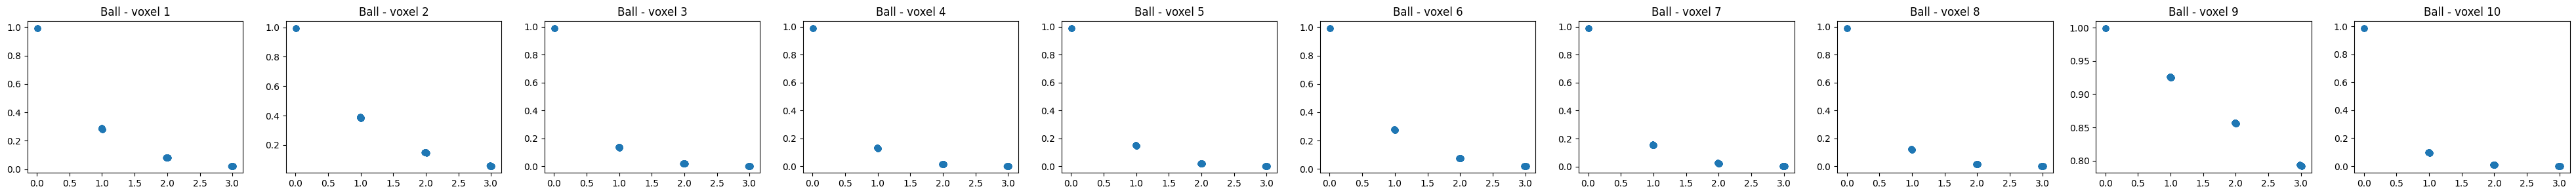

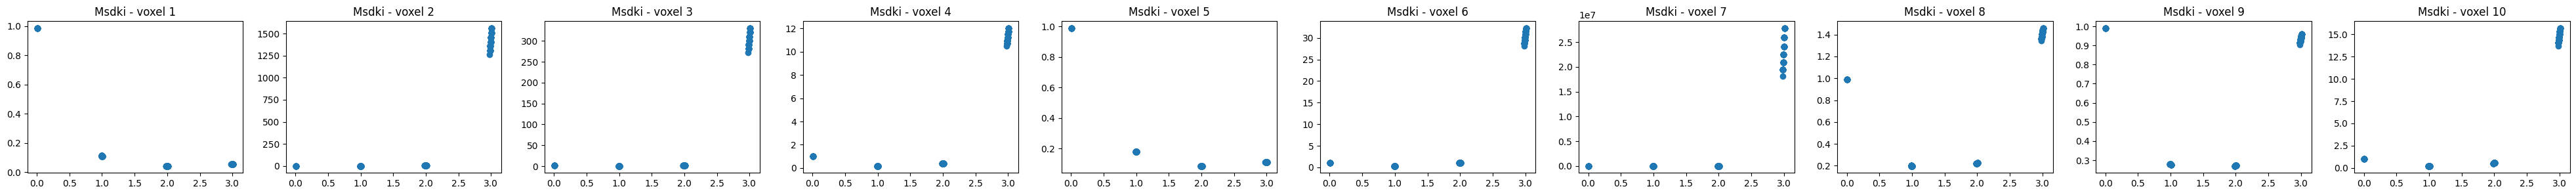

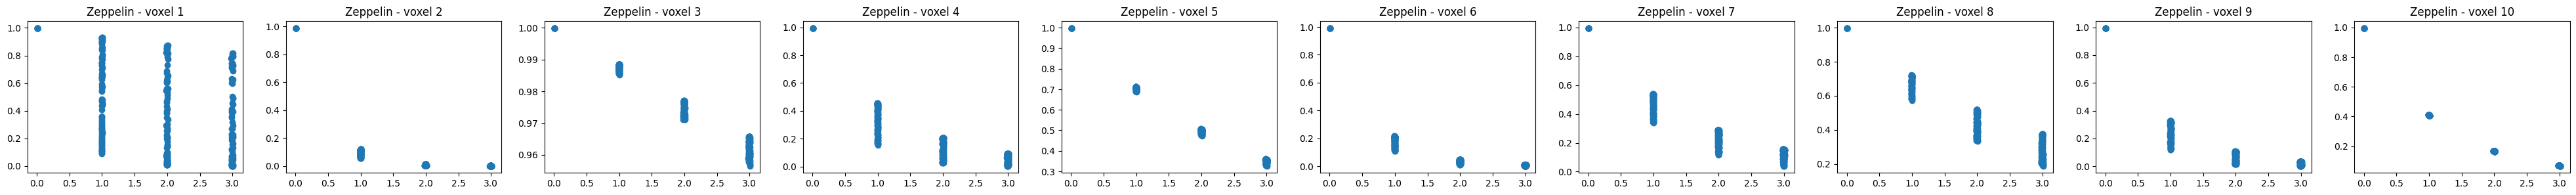

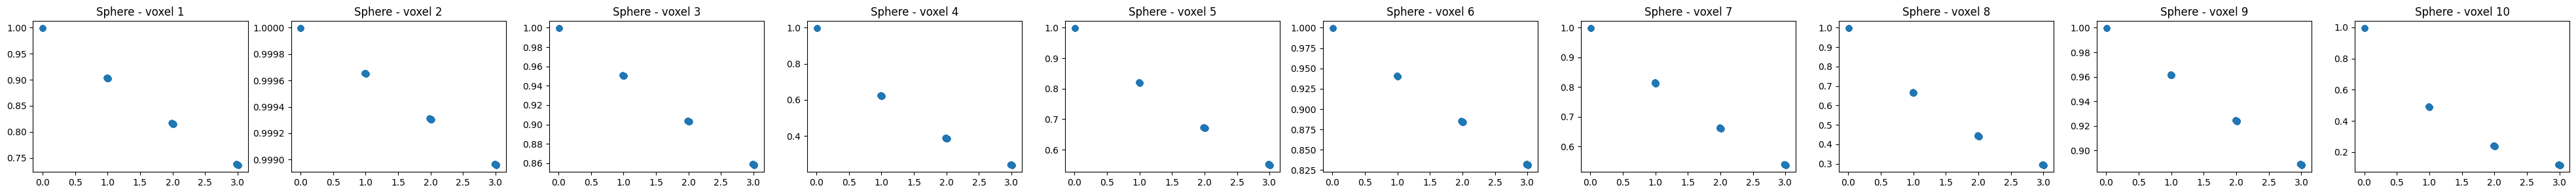

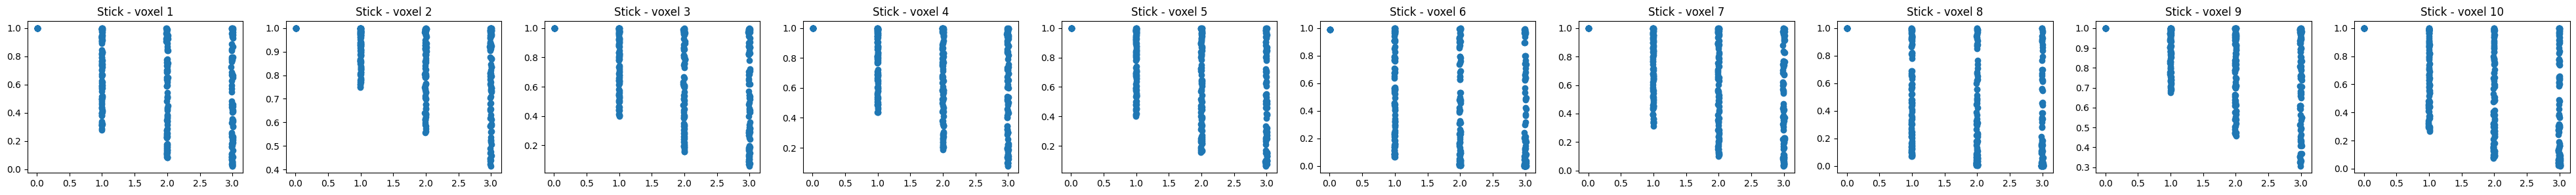

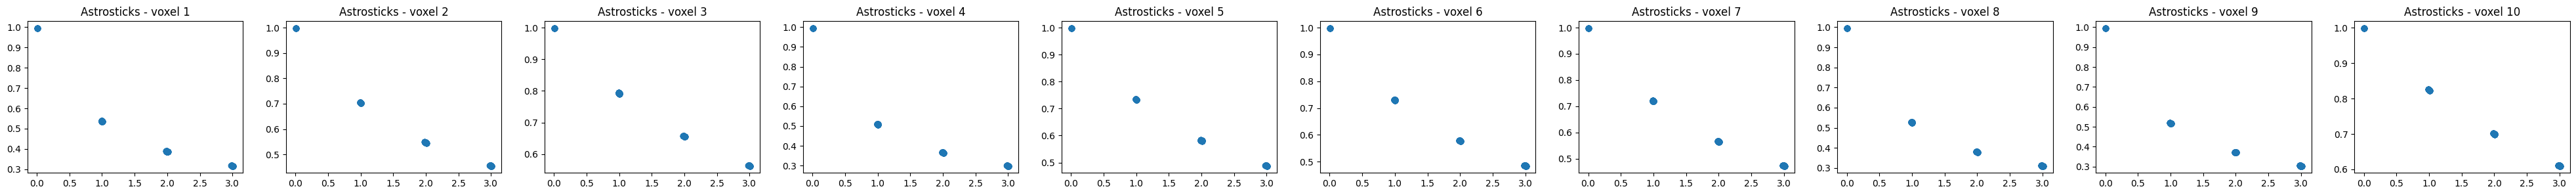

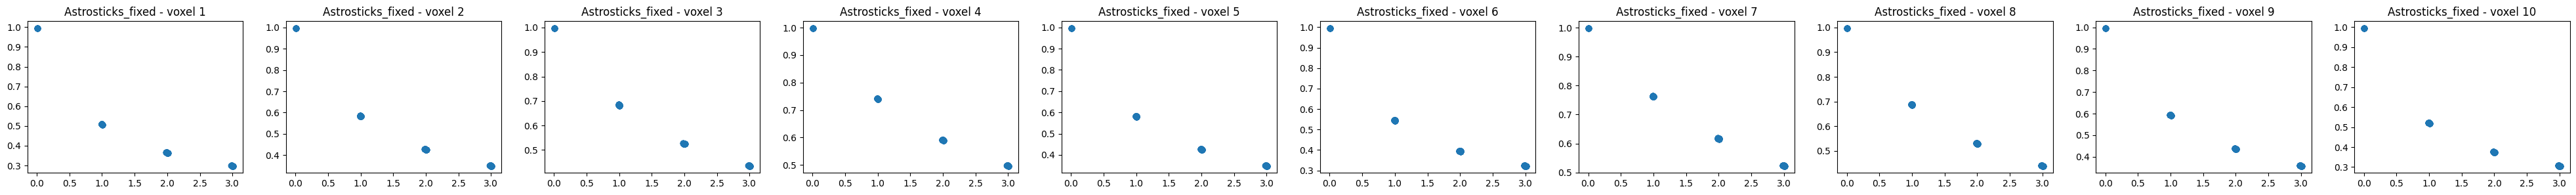

In [27]:
for compartment in compartments:
    n_voxels = S[compartment].shape[1]
    _, ax = plt.subplots(1, n_voxels, figsize=(5 * n_voxels, 3))
    for i in range(n_voxels):
        ax[i].plot(grad.bvalues, S[compartment][0,i,:],'o')
        ax[i].set_title(f"{compartment} - voxel {i+1}")

In [ ]:
import re

re.findall('([A-Z][a-z]+)', "Standardwm")

['Standardwm']

In [ ]:
modelfunc["Ball"].compartments[0]